# Adult-PMR3508

Esse trabalho se propõe a realizar a predição da renda anual a partir de dados demográficos contidos na base Adult, disponível no repositório ICU. Para tanto, serão comparados quatro algoritmos, a saber, Regressão Logística, SVM, Random Forest e XGBoost, aliados técnicas de pré-processamento.

## 1. Importação das bibliotecas

In [1]:
!pip install missingno -q

In [2]:
#matemática
import numpy as np
import pandas as pd
pd.set_option('display.float_format', lambda x: '%.3f' % x)

#gráficos
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

#missing data
import missingno as msno

#pré-processamento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#cross validation
from sklearn.model_selection import KFold

#hyperopt
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK

#random search
from sklearn.model_selection import  RandomizedSearchCV

#regressão logística
from sklearn.linear_model import LogisticRegression

#SVM
from sklearn.svm import SVC

#random forest
from sklearn.ensemble import RandomForestClassifier

#xgboost
import xgboost as xgb

#avaliação
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, RocCurveDisplay

#matriz de confusão
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

## 2. Importação dos dados

In [3]:

df = pd.read_csv("/kaggle/input/adult-pmr3508/train_data.csv" ,
        engine = "python",
        sep=r'\s*,\s*',
        na_values="?")

final_test = pd.read_csv("/kaggle/input/adult-pmr3508/test_data.csv",
        engine = "python",
        sep=r'\s*,\s*',
        na_values="?")

In [4]:
df.shape #verificação do número de linhas e colunas

(32560, 16)

In [5]:
df.head()

,Id,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,16280,34,Private,204991,Some-college,10,Divorced,Exec-managerial,Own-child,White,Male,0,0,44,United-States,<=50K
1,16281,58,Local-gov,310085,10th,6,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,40,United-States,<=50K
2,16282,25,Private,146117,Some-college,10,Never-married,Machine-op-inspct,Not-in-family,White,Male,0,0,42,United-States,<=50K
3,16283,24,Private,138938,Some-college,10,Divorced,Adm-clerical,Not-in-family,White,Female,0,0,40,United-States,<=50K
4,16284,57,Self-emp-inc,258883,HS-grad,9,Married-civ-spouse,Transport-moving,Husband,White,Male,5178,0,60,Hungary,>50K


In [6]:
#separação do desfecho das variáveis preditoras
X = df.drop(columns = ["income", "Id"])
y = df["income"]
final_test = final_test.drop(columns = "Id")

In [7]:
X.shape

(32560, 14)

In [8]:
y

0        <=50K
1        <=50K
2        <=50K
3        <=50K
4         >50K
         ...  
32555     >50K
32556    <=50K
32557    <=50K
32558    <=50K
32559    <=50K
Name: income, Length: 32560, dtype: object

## 3. Análise exploratória de dados

### 3.1 Informações gerais

In [9]:
#obtenção de informações sobre os tipos de variáveis no conjunto de dados
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32560 entries, 0 to 32559
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32560 non-null  int64 
 1   workclass       30724 non-null  object
 2   fnlwgt          32560 non-null  int64 
 3   education       32560 non-null  object
 4   education.num   32560 non-null  int64 
 5   marital.status  32560 non-null  object
 6   occupation      30717 non-null  object
 7   relationship    32560 non-null  object
 8   race            32560 non-null  object
 9   sex             32560 non-null  object
 10  capital.gain    32560 non-null  int64 
 11  capital.loss    32560 non-null  int64 
 12  hours.per.week  32560 non-null  int64 
 13  native.country  31977 non-null  object
dtypes: int64(6), object(8)
memory usage: 3.5+ MB


In [10]:
#separação das variáveis em categóricas e numéricas a fim de facilitar seu processamento
numeric_features = ["age", "fnlwgt", "capital.gain", "capital.loss", "hours.per.week", "education.num"]
categorical_features = ["workclass",  "marital.status", "occupation", "relationship", "race", "sex", "native.country"]

### 3.2 Análise de missing values

Nesse banco de dados, os valores faltantes estão representados pelo símbolo '?', portanto, o substituiremos por NaN, para facilitar sua vizualização e processamento.

In [11]:
X.replace(to_replace='?',value= np.nan,inplace=True) #substituir '?' por missing

<Axes: >

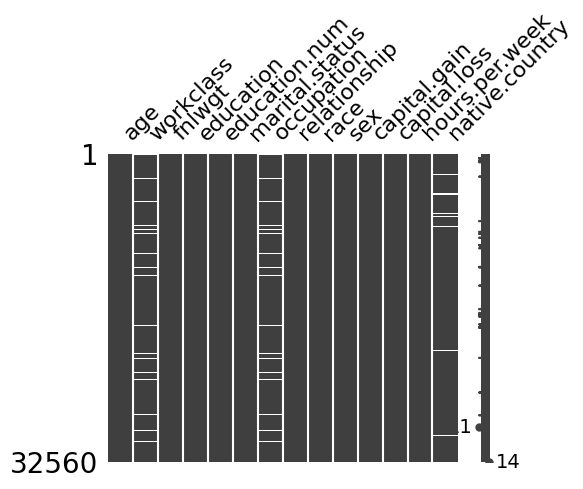

In [12]:
msno.matrix(X, figsize = (5, 4)) #matriz de valores faltante

In [13]:
X.isna().sum().sort_values(ascending = False) #verificar número de valores faltantes em cada variável

occupation        1843
workclass         1836
native.country     583
age                  0
fnlwgt               0
education            0
education.num        0
marital.status       0
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
dtype: int64

Vemos que três variáveis possuem valores faltantes, sendo que, conforme pode ser visto da matriz, sua ausência parece apresentar alto grau de conservação (os mesmos índices apresentam valores faltantes nas variáveis).

#### 3.2.1 Remoção de variáveis com mais de 80% de dados faltantes

In [14]:
for coluna in X.columns:
    prop = X[coluna].isna().astype(int).sum()/len(X) #cálculo da proporção de valores faltantes na coluna
    if prop > 0.8:
        X.drop(columns = coluna) #remover coluna com mais de 80% de missing
        print("A coluna %s for removida"%coluna) #imprimir colunas removidas, para controle

Aparentemente, não foi necessária a remoção de nenhuma coluna devido a insuficiência de dados.

### 3.3 Análise descritiva

In [15]:
X.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32560.000,32560.000,32560.000,32560.000,32560.000,32560.000
mean,38.582,189781.814,10.081,1077.615,87.307,40.437
std,13.641,105549.765,2.573,7385.403,402.966,12.348
min,17.000,12285.000,1.000,0.000,0.000,1.000
25%,28.000,117831.500,9.000,0.000,0.000,40.000
50%,37.000,178363.000,10.000,0.000,0.000,40.000
75%,48.000,237054.500,12.000,0.000,0.000,45.000
max,90.000,1484705.000,16.000,99999.000,4356.000,99.000


### 3.4 Visualização gráfica

#### 3.4.1 BoxPlots

In [16]:
for feature in numeric_features:
    fig = px.box(X, x=feature, color=y, title=feature)
    fig.show()

Analisando os boxplots das variáveis numéricas estratificados pelo desfecho, observamos que há uma diferença significativa entre grupos em se tratando das variáveis idade e número de anos de estudo, sugerindo que estes devem ser preditores fortes do desfecho.

#### 3.4.2 Histogramas

In [17]:
for i, feature in enumerate(numeric_features, 1):
    fig = px.histogram(X, x=feature, color=y, barmode='overlay',
                   title=feature)
    fig.show()

Novamente, vemos que a distribuição entre grupos estratificados pelo desfecho é significativamente diferente, sobretudo na variável idade.

## 4. Pré-processamento de Dados

### 4.1. Divisão treino-teste

Separamos 30% dos dados para simular dados reais (inéditos) para testar o modelo, enquanto os demais 70% serão usados no treinamento.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7) #divisão treino-teste com razão 70:30

O desfecho será representado como uma variável binária tal que 0 representa o grupo que recebe menos ou igual a 50K, ao passo que 1 indica aquelas pessoas que recebem valores maiores que 50K.

In [19]:
y_train, y_test = y_train.apply(lambda x: 1 if x == '>50K' else 0), y_test.apply(lambda x: 1 if x == '>50K' else 0) #binarização do desfecho

### 4.2 Processamento de variáveis categóricas

In [20]:
categorical_features

['workclass',
 'marital.status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native.country']

#### 4.2.1 Workclass

In [21]:
X_train['workclass'].isna().sum() #verificação do número de dados faltantes

1259

In [22]:
X_train['workclass'] = X_train['workclass'].fillna("Unknown") #criação de classe "Unknown" para dados missing

In [23]:
X_train['workclass'].value_counts(normalize=True) #verificar distribuição das classes da variável

workclass
Private            0.696
Self-emp-not-inc   0.078
Local-gov          0.065
Unknown            0.055
State-gov          0.041
Self-emp-inc       0.034
Federal-gov        0.029
Without-pay        0.000
Never-worked       0.000
Name: proportion, dtype: float64

Nota-se que há uma prevalência da classe de trabalhadores privados (70%), mas as demais classes são razoavelmente bem distribuídas.

In [24]:
#gerar histograma de classe de trabalho estratificada por desfecho no conjunto de treinamento
#note que o desfecho do conjunto de teste permanece desconhecido
fig = px.histogram(X_train, x='workclass', color=y_train, barmode='overlay',
                   title=feature)
fig.show()

In [25]:
pd.crosstab(X_train["workclass"], y_train, normalize='index').sort_values(by=1,
ascending = False) #verificação do percentual de desfecho por classe no conjunto de treinamento

income,0,1
workclass,,
Self-emp-inc,0.431,0.569
Federal-gov,0.601,0.399
Local-gov,0.697,0.303
Self-emp-not-inc,0.725,0.275
State-gov,0.727,0.273
Private,0.781,0.219
Unknown,0.890,0.110
Never-worked,1.000,0.000
Without-pay,1.000,0.000


Avaliando as proporções de desfecho por classe no conjunto de treinamento, criaremos novas categorias que agrupem profissões com percentuais similares de desfecho.

In [26]:
#separar profissões por receita anual
high = [ 'Self-emp-inc', 'Federal-gov']
medium = [ 'Local-gov','Self-emp-not-inc','State-gov',  'Private']
low = ['Unknown', 'Never-worked', 'Without-pay']


Utilizaremos essas novas categorias para realizar o one hot encoding dessa variável, nos conjuntos de treinamento e teste.

In [27]:
X_train["workclass_high"] = X_train["workclass"].apply(lambda x: 1 if x in high else 0)
X_train["workclass_medium"] = X_train["workclass"].apply(lambda x: 1 if x in medium else 0)
X_train["workclass_low"] = X_train["workclass"].apply(lambda x: 1 if x in low else 0)
X_train = X_train.drop(columns = "workclass")

In [28]:
X_test["workclass_high"] = X_test["workclass"].apply(lambda x: 1 if x in high else 0)
X_test["workclass_medium"] = X_test["workclass"].apply(lambda x: 1 if x in medium else 0)
X_test["workclass_low"] = X_test["workclass"].apply(lambda x: 1 if x in low else 0)
X_test = X_test.drop(columns = "workclass")

In [29]:
final_test["workclass_high"] = final_test["workclass"].apply(lambda x: 1 if x in high else 0)
final_test["workclass_medium"] = final_test["workclass"].apply(lambda x: 1 if x in medium else 0)
final_test["workclass_low"] = final_test["workclass"].apply(lambda x: 1 if x in low else 0)
final_test = final_test.drop(columns = "workclass")

#### 4.2.2 Education

In [30]:
X_train['education'].value_counts(normalize=True) #verificação da distribuição entre classes da variável

education
HS-grad        0.320
Some-college   0.224
Bachelors      0.164
Masters        0.054
Assoc-voc      0.042
11th           0.036
Assoc-acdm     0.033
10th           0.029
7th-8th        0.020
Prof-school    0.018
9th            0.016
12th           0.014
Doctorate      0.013
5th-6th        0.010
1st-4th        0.005
Preschool      0.002
Name: proportion, dtype: float64

In [31]:
#histograma estratficado pelo desfecho do conjunto de treinamento
fig = px.histogram(X_train, x='education', color=y_train, barmode='overlay',
                   title=feature)
fig.show()

In [32]:
#proporção de desfecho em cada classe avaliada sobre o conjunto de treinamento
crosstab= pd.crosstab(X_train["education"], y_train, normalize='index').sort_values(by=1,
ascending = False)
crosstab

income,0,1
education,,
Doctorate,0.240,0.760
Prof-school,0.261,0.739
Masters,0.443,0.557
Bachelors,0.586,0.414
Assoc-voc,0.732,0.268
Assoc-acdm,0.746,0.254
Some-college,0.810,0.190
HS-grad,0.840,0.160
12th,0.921,0.079


In [33]:
#estabelecer novas categorias de acordo com as proporções de desfecho
high = []
medium= []
low= []

#os valores de corte (0.400 e 0.150) foram estipulados observando o padrão de dispersão dos dados na tabela anterior
for feature in set(X_train['education'].values):
    if float(crosstab.loc[feature][1]) > 0.400:
        high.append(feature)
    elif float(crosstab.loc[feature][1]) > 0.150:
        medium.append(feature)
    else:
        low.append(feature)

In [34]:
#one hot encoding utilizando as novas categorias agrupadas
X_train["education_high"] = X_train["education"].apply(lambda x: 1 if x in high else 0)
X_train["education_medium"] = X_train["education"].apply(lambda x: 1 if x in medium else 0)
X_train["education_low"] = X_train["education"].apply(lambda x: 1 if x in low else 0)
X_train = X_train.drop(columns = "education")

In [35]:
#replicação do one hot encoding no conjunto de teste (garantir que hajam as mesmas colunas)
X_test["education_high"] = X_test["education"].apply(lambda x: 1 if x in high else 0)
X_test["education_medium"] = X_test["education"].apply(lambda x: 1 if x in medium else 0)
X_test["education_low"] = X_test["education"].apply(lambda x: 1 if x in low else 0)
X_test = X_test.drop(columns = "education")

In [36]:
final_test["education_high"] = final_test["education"].apply(lambda x: 1 if x in high else 0)
final_test["education_medium"] = final_test["education"].apply(lambda x: 1 if x in medium else 0)
final_test["education_low"] = final_test["education"].apply(lambda x: 1 if x in low else 0)
final_test = final_test.drop(columns = "education")

### 4.3 Marital status

In [37]:
X_train['marital.status'].value_counts(normalize=True) #distribuição das classes

marital.status
Married-civ-spouse      0.461
Never-married           0.328
Divorced                0.135
Separated               0.032
Widowed                 0.030
Married-spouse-absent   0.012
Married-AF-spouse       0.001
Name: proportion, dtype: float64

In [38]:
#histograma estratificado pelo desfecho no conjunto de treinamento
fig = px.histogram(X_train, x='marital.status', color=y_train, barmode='overlay')
fig.show()

Notamos que, nesse caso, o que realmente muda o perfil de desfecho é a pessoa ser casada ou não. Dessa maneira, adaptaremos a variável para uma variável binária, que recebe 1 caso a pessoa seja casada e 0, caso contrário.

In [39]:
#binariação da variável
X_train['marital.status'] = X_train['marital.status'].apply(lambda x: 1 if x == "Married-civ-spouse" else 0)
X_test['marital.status'] = X_test['marital.status'].apply(lambda x: 1 if x == "Married-civ-spouse" else 0)
final_test['marital.status'] = final_test['marital.status'].apply(lambda x: 1 if x == "Married-civ-spouse" else 0)

In [40]:
X_train['marital.status'] #verificar nova variável

21359    1
8075     0
19158    1
26343    0
12547    1
        ..
25978    0
24040    1
26831    0
21673    0
26883    0
Name: marital.status, Length: 22792, dtype: int64

### 4.4 Occupation

In [41]:
X_train['occupation'].isna().any() #verificar se existem valores faltantes

True

In [42]:
#Incluiremos os valores faltantes na classe "outros"
X_train['occupation'] = X_train['occupation'].fillna("Other-service")
X_test['occupation'] = X_test['occupation'].fillna("Other-service")
final_test['occupation'] = final_test['occupation'].fillna("Other-service")

In [43]:
X_train['occupation'].value_counts(normalize=True) #verificação da distribuição de classes

occupation
Other-service       0.157
Prof-specialty      0.127
Exec-managerial     0.127
Craft-repair        0.126
Adm-clerical        0.114
Sales               0.114
Machine-op-inspct   0.061
Transport-moving    0.049
Handlers-cleaners   0.041
Farming-fishing     0.030
Tech-support        0.028
Protective-serv     0.020
Priv-house-serv     0.005
Armed-Forces        0.000
Name: proportion, dtype: float64

In [44]:
#histograma estratificado pelo desfecho no conjunto de treinamento
fig = px.histogram(X_train, x='occupation', color=y_train, barmode='overlay')
fig.show()

In [45]:
#verificarproporção de desfecho por classe no conjunto de treinamento
crosstab= pd.crosstab(X_train["occupation"], y_train, normalize='index').sort_values(by=1,
ascending = False)
crosstab

income,0,1
occupation,,
Exec-managerial,0.517,0.483
Prof-specialty,0.548,0.452
Protective-serv,0.657,0.343
Tech-support,0.689,0.311
Sales,0.730,0.270
Craft-repair,0.772,0.228
Transport-moving,0.810,0.190
Adm-clerical,0.864,0.136
Machine-op-inspct,0.881,0.119


In [46]:
#estabelecer novas categorias por proporção de desfecho nos valores de treino e teste
high = []
medium= []
low= []
#valores de corte estabelecidos por meio da observação do padrão de dispersão dos dados
for feature in set(X_train['occupation'].values):
    if float(crosstab.loc[feature][1]) > 0.400:
        high.append(feature)
    elif float(crosstab.loc[feature][1]) > 0.200:
        medium.append(feature)
    else:
        low.append(feature)

In [47]:
#one hot encoding com base nas novas categorias
X_train["occupation_high"] = X_train["occupation"].apply(lambda x: 1 if x in high else 0)
X_train["occupation_medium"] = X_train["occupation"].apply(lambda x: 1 if x in medium else 0)
X_train["occupation_low"] = X_train["occupation"].apply(lambda x: 1 if x in low else 0)
X_train = X_train.drop(columns = "occupation")

In [48]:
#replicação do one hot encoding no conjunto de teste
X_test["occupation_high"] = X_test["occupation"].apply(lambda x: 1 if x in high else 0)
X_test["occupation_medium"] = X_test["occupation"].apply(lambda x: 1 if x in medium else 0)
X_test["occupation_low"] = X_test["occupation"].apply(lambda x: 1 if x in low else 0)
X_test = X_test.drop(columns = "occupation")

In [49]:
#replicação do one hot encoding no conjunto de teste
final_test["occupation_high"] = final_test["occupation"].apply(lambda x: 1 if x in high else 0)
final_test["occupation_medium"] = final_test["occupation"].apply(lambda x: 1 if x in medium else 0)
final_test["occupation_low"] = final_test["occupation"].apply(lambda x: 1 if x in low else 0)
final_test = final_test.drop(columns = "occupation")

### 4.5 Relashionship

In [50]:
X_train['relationship'].value_counts(normalize=True) #verificação da proporção de classes

relationship
Husband          0.404
Not-in-family    0.255
Own-child        0.155
Unmarried        0.105
Wife             0.050
Other-relative   0.030
Name: proportion, dtype: float64

In [51]:
#histograma estratificado por desfecho no conjunto de treinamento
fig = px.histogram(X_train, x='relationship', color=y_train, barmode='overlay')
fig.show()

Nota-se que aqui a diferença é ser casado ou não, como essa informação já foi registrada em marital status, não é necessário incluir essa variável.

In [52]:
#remoção da coluna, visto que ela é redundante com 'marital status'
X_train = X_train.drop(columns = "relationship")
X_test = X_test.drop(columns = "relationship")
final_test = final_test.drop(columns = "relationship")

### 4.6 Race

In [53]:
X_train['race'].value_counts(normalize=True) #verificar proporção de classes

race
White                0.855
Black                0.095
Asian-Pac-Islander   0.033
Amer-Indian-Eskimo   0.010
Other                0.008
Name: proportion, dtype: float64

In [54]:
#histograma estratificado pelo desfecho no conjunto de teste
fig = px.histogram(X_train, x='race', color=y_train, barmode='overlay')
fig.show()

Essa variável é muito desbalanceada em termos de número de observações, portanto não é informativa para o modelo, visto que as classes de pessoas não brancas somadas não ultrapassam 15%, sendo insuficientemente representadas para permitir predições relevantes.

In [55]:
#eliminar coluna
X_train= X_train.drop(columns = "race")
X_test = X_test.drop(columns = "race")
final_test = final_test.drop(columns = "race")

In [56]:
X_train.head() #verificar se a coluna foi corretamente eliminada

,age,fnlwgt,education.num,marital.status,sex,capital.gain,capital.loss,hours.per.week,native.country,workclass_high,workclass_medium,workclass_low,education_high,education_medium,education_low,occupation_high,occupation_medium,occupation_low
21359,25,200318,9,1,Male,0,0,60,United-States,0,1,0,0,1,0,0,0,1
8075,51,123011,13,0,Male,0,2559,50,United-States,0,1,0,1,0,0,1,0,0
19158,24,67586,11,1,Female,0,0,35,United-States,0,0,1,0,1,0,0,0,1
26343,42,198316,11,0,Male,0,0,35,United-States,0,1,0,0,1,0,0,1,0
12547,68,108683,10,1,Female,0,0,12,United-States,0,0,1,0,1,0,0,0,1


### 4.7 Sex

Nesse caso, basta binarizar a variável.

In [57]:
X_train['sex'] = X_train['sex'].apply(lambda x: 1 if x == "Male" else 0)
X_test['sex'] = X_test['sex'].apply(lambda x: 1 if x == "Male" else 0)
final_test['sex'] = final_test['sex'].apply(lambda x: 1 if x == "Male" else 0)

In [58]:
#histograma estratificado pelo desfecho no conjunto de teste
fig = px.histogram(X_train, x='sex', color=y_train, barmode='overlay')
fig.show()

De fato, as observações sugerem um forte viés salarial, com maiores valores para os indivíduos do sexo masculino.

### 4.8 Native Country

In [59]:
X_train['native.country'].value_counts(normalize=True) #verificação da distribuição de classes

native.country
United-States                0.910
Mexico                       0.020
Philippines                  0.007
Germany                      0.005
Canada                       0.004
Puerto-Rico                  0.004
El-Salvador                  0.003
India                        0.003
England                      0.003
Cuba                         0.003
China                        0.003
South                        0.003
Italy                        0.002
Jamaica                      0.002
Dominican-Republic           0.002
Vietnam                      0.002
Guatemala                    0.002
Poland                       0.002
Japan                        0.002
Columbia                     0.002
Taiwan                       0.001
Haiti                        0.001
Portugal                     0.001
Nicaragua                    0.001
Iran                         0.001
Peru                         0.001
Ecuador                      0.001
Greece                       0.001
Franc

Essa variável é muito desbalanceada em termos de número de observações, portanto não é informativa para o modelo, visto que os nativos dos Estados Unidos representam mais de 90% das observações, com a próxima classe mais frequente (México) não chegando a 2%.

In [60]:
#eliminação da coluna dos conjuntod=s de treino e teste
X_train= X_train.drop(columns = "native.country")
X_test = X_test.drop(columns = "native.country")
final_test = final_test.drop(columns = "native.country")

### 4.9 Verificar consistência

In [61]:
#indicar se há alguma coluna presente no conjunto de treinamento que não está presente no teste
for coluna in X_train.columns:
    if coluna not in X_test.columns:
        print(coluna)

In [62]:
#indicar se há alguma coluna presente no conjunto de teste que não está presente no treinamento
for coluna in X_test.columns:
    if coluna not in X_train.columns:
        print(coluna)

Todas as colunas estão consistentes entre treino e teste após a criação das novas categorias.

In [63]:
X_train.head() #checagem do conjunto de dados após tratamento dos atributos categóricos

,age,fnlwgt,education.num,marital.status,sex,capital.gain,capital.loss,hours.per.week,workclass_high,workclass_medium,workclass_low,education_high,education_medium,education_low,occupation_high,occupation_medium,occupation_low
21359,25,200318,9,1,1,0,0,60,0,1,0,0,1,0,0,0,1
8075,51,123011,13,0,1,0,2559,50,0,1,0,1,0,0,1,0,0
19158,24,67586,11,1,0,0,0,35,0,0,1,0,1,0,0,0,1
26343,42,198316,11,0,1,0,0,35,0,1,0,0,1,0,0,1,0
12547,68,108683,10,1,0,0,0,12,0,0,1,0,1,0,0,0,1


## 5. Tratamento das variáveis numéricas

Para assegurar melhor performance do modelo, normalizaremos todas as variáveis numéricas por uma transformação z-score, de modo a evitar que as medidas de distância realizadas pelo KNN sejam distorcidas pelas diferentes escalas acabando por privilegiar alguma variável em detrimento das demais.

In [64]:
#transformação z-score
scaler = StandardScaler()

for feature in numeric_features:
    scaler.fit(X_train[[feature]])
    X_train[feature] = scaler.transform(X_train[[feature]])
    X_test[feature] = scaler.transform(X_test[[feature]])
    final_test[feature] = scaler.transform(final_test[[feature]])


In [65]:
X_train.head() #checar se todas as variáveis de treinamento foram corretamente normalizadas

,age,fnlwgt,education.num,marital.status,sex,capital.gain,capital.loss,hours.per.week,workclass_high,workclass_medium,workclass_low,education_high,education_medium,education_low,occupation_high,occupation_medium,occupation_low
21359,-0.996,0.100,-0.421,1,1,-0.146,-0.214,1.583,0,1,0,0,1,0,0,0,1
8075,0.909,-0.635,1.129,0,1,-0.146,6.188,0.776,0,1,0,1,0,0,1,0,0
19158,-1.069,-1.163,0.354,1,0,-0.146,-0.214,-0.436,0,0,1,0,1,0,0,0,1
26343,0.250,0.081,0.354,0,1,-0.146,-0.214,-0.436,0,1,0,0,1,0,0,1,0
12547,2.155,-0.772,-0.033,1,0,-0.146,-0.214,-2.293,0,0,1,0,1,0,0,0,1


In [66]:
X_test.head()#checar se todas as variáveis de teste foram corretamente normalizadas

,age,fnlwgt,education.num,marital.status,sex,capital.gain,capital.loss,hours.per.week,workclass_high,workclass_medium,workclass_low,education_high,education_medium,education_low,occupation_high,occupation_medium,occupation_low
20530,-1.142,-0.413,1.129,0,1,-0.146,-0.214,1.180,0,0,0,1,0,0,0,0,1
30452,0.983,-0.577,-0.421,0,0,-0.146,-0.214,-0.032,1,0,0,0,1,0,0,0,1
24104,-0.556,-0.197,1.129,0,1,-0.146,-0.214,-0.032,0,1,0,1,0,0,0,1,0
1618,2.375,-0.775,-0.033,1,1,0.305,-0.214,-1.647,0,0,0,0,1,0,0,0,1
13671,0.397,0.176,-0.421,1,0,-0.146,-0.214,0.372,0,1,0,0,1,0,0,0,1


## 6. Verificar colinearidade

Variáveis altamente correlacionadas podem comprometer a performance do modelo, portanto, criaremos uma matriz de correlação e verificaremos a colinearidade entre variáveis a fim de evitar esse fenômeno.

In [67]:
#criação de matriz de correlação
corr = X_train[X_train.columns].corr()
corr

,age,fnlwgt,education.num,marital.status,sex,capital.gain,capital.loss,hours.per.week,workclass_high,workclass_medium,workclass_low,education_high,education_medium,education_low,occupation_high,occupation_medium,occupation_low
age,1.000,-0.074,0.041,0.320,0.087,0.077,0.061,0.069,0.115,-0.112,0.036,0.100,-0.087,-0.003,0.121,-0.021,-0.087
fnlwgt,-0.074,1.000,-0.042,-0.022,0.026,0.004,-0.013,-0.019,-0.021,0.017,-0.001,-0.022,-0.005,0.035,-0.031,0.016,0.012
education.num,0.041,-0.042,1.000,0.085,0.007,0.125,0.075,0.147,0.097,-0.020,-0.075,0.766,-0.212,-0.675,0.477,-0.062,-0.360
marital.status,0.320,-0.022,0.085,1.000,0.427,0.089,0.079,0.215,0.087,-0.031,-0.049,0.107,-0.066,-0.042,0.114,0.099,-0.189
sex,0.087,0.026,0.007,0.427,1.000,0.046,0.044,0.225,0.066,-0.008,-0.058,0.047,-0.057,0.023,0.005,0.169,-0.158
capital.gain,0.077,0.004,0.125,0.089,0.046,1.000,-0.031,0.074,0.070,-0.036,-0.024,0.128,-0.085,-0.043,0.111,-0.010,-0.088
capital.loss,0.061,-0.013,0.075,0.079,0.044,-0.031,1.000,0.054,0.029,-0.011,-0.015,0.075,-0.044,-0.032,0.067,0.009,-0.067
hours.per.week,0.069,-0.019,0.147,0.215,0.225,0.074,0.054,1.000,0.108,0.038,-0.169,0.142,-0.045,-0.117,0.156,0.052,-0.183
workclass_high,0.115,-0.021,0.097,0.087,0.066,0.070,0.029,0.108,1.000,-0.708,-0.064,0.081,-0.029,-0.062,0.111,-0.002,-0.095
workclass_medium,-0.112,0.017,-0.020,-0.031,-0.008,-0.036,-0.011,0.038,-0.708,1.000,-0.660,-0.019,0.019,-0.002,0.017,0.111,-0.116


In [68]:
#eliminação de variáveis com mais de 80% de correlação
for i in range(len(corr)):
    for j in range(len(corr)):
         if i!=j and corr.iloc[i, j] > 0.8:
             X_train = X_train.drop(X_train.columns[i], axis=1)
             X_test = X_test.drop(X_train.columns[i], axis=1)
             final_test = final_test.drop(X_train.columns[i], axis=1)
             print("A coluna %s for removida"%coluna) #imprimir coluna eliminada, para controle

Verificamos, nesse caso, que não existiam variáveis com correlação maior que 80%, portanto, todas as colunas foram mantidas.

##7. Regressão Logística

O primeiro modelo a ser testado será a regressão logística, um algoritmo plug-in de classificação que calcula a probabilidade do rótulo dadas as observações por meio da otimização da sua respectiva função logit.

Para encontrar os melhores hiperparâmetros para esse modelo, utilizaremos otimiação bayesiana (HyperOpt) acoplada a validação cruzada. A métrica escolhida para avaliação da performance foi a área abaixo da curva ROC (AUC). Ela foi preferida em relação à acurácia por fornecer uma visão mais holística do modelo, balanceando a taxa de positivos verdadeiros e falsos positivos e, assim, evitando a priorização de modelos que realizem overfitting.

In [69]:
#definição do espaço de busca de hiperparâmetros
space = {
    'C': hp.loguniform('C', -5, 5),
    'solver': hp.choice('solver', ['liblinear', 'newton-cg', 'lbfgs', 'saga']),
    'class_weight': hp.choice('class_weight', [None, 'balanced']),
    'fit_intercept': hp.choice('fit_intercept', [True, False])
}

In [70]:
#definição da função objetivo
def objective(params):

    model = LogisticRegression(
        C=params['C'],
        solver=params['solver'],
        max_iter=100,
        class_weight=params['class_weight'],
        fit_intercept=params['fit_intercept']
    )

    auc_scores = []
    X_train_np = np.array(X_train)
    y_train_np = np.array(y_train)

    #10-fold cross validation
    kf = KFold(n_splits=10, shuffle=True, random_state=42)

    for train_index, val_index in kf.split(X_train_np):
      x_t, x_v = X_train_np[train_index], X_train_np[val_index]
      y_t, y_v = y_train_np[train_index], y_train_np[val_index]

      model.fit(x_t, y_t)
      preds = model.predict_proba(x_v)[:, 1]
      auc = roc_auc_score(y_v, preds)
      auc_scores.append(auc)

    auc = np.mean(auc_scores)
    return {'loss': -auc, 'status': STATUS_OK}

In [71]:
trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=50, trials=trials)

print("Melhores hiperparâmetros: ", best)

 24%|██▍       | 12/50 [00:22<01:11,  1.88s/trial, best loss: -0.9009024106066367]

/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge


/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge


/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge


/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge


/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge


/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge


/opt/conda/lib/python3.10/site-pac

 26%|██▌       | 13/50 [00:31<02:33,  4.15s/trial, best loss: -0.9009024106066367]

/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge




 42%|████▏     | 21/50 [00:47<01:04,  2.23s/trial, best loss: -0.9009036271843749]

...

 70%|███████   | 35/50 [01:34<00:48,  3.20s/trial, best loss: -0.9009036271843749]

/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge


/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge


/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge


/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge


/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge


/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge


/opt/conda/lib/python3.10/site-pac

 72%|███████▏  | 36/50 [01:44<01:13,  5.27s/trial, best loss: -0.9009036271843749]

/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge




100%|██████████| 50/50 [02:10<00:00,  2.60s/trial, best loss: -0.9009036271843749]
Melhores hiperparâmetros:  {'C': 18.685244927602472, 'class_weight': 1, 'fit_intercept': 0, 'solver': 3}


In [72]:
param_map = {
            'solver': ['liblinear', 'newton-cg', 'lbfgs', 'saga'],
            'class_weight': [None, 'balanced'],
            'fit_intercept':[True, False]
            }

best_params = {
        'C': float(best['C']),
        'solver': param_map['solver'][best['solver']],
        'class_weight': param_map['class_weight'][best['class_weight']],
        'fit_intercept': param_map['fit_intercept'][best['fit_intercept']]
}

logreg_final_model = LogisticRegression(**best_params)
logreg_final_model.fit(X_train, y_train)

LogisticRegression(C=18.685244927602472, class_weight='balanced', solver='saga')

In [73]:
#avaliação da performance no conjunto de treinamento com 10-fold cross validation (random seed diferente)
kf = KFold(n_splits=10, shuffle=True, random_state=43)

auc_scores = []
X_train_np = np.array(X_train)
y_train_np = np.array(y_train)

for train_index, val_index in kf.split(X_train_np):
    x_t, x_v = X_train_np[train_index], X_train_np[val_index]
    y_t, y_v = y_train_np[train_index], y_train_np[val_index]

    logreg_final_model.fit(x_t, y_t)
    logreg_eval_preds = logreg_final_model.predict_proba(x_v)[:, 1]
    auc = roc_auc_score(y_v, logreg_eval_preds)
    auc_scores.append(auc)

mean_auc = np.mean(auc_scores)
print(f"Média da AUC com cross validation: {mean_auc:.4f}")

Média da AUC com cross validation: 0.9007


Utilizando o modelo com os hiperparâmetros ajustados vemos que, no conjunto de treinamento, obtemos uma área abaixo da curva de 0.90 utilizando validação cruzada, o que, conforme a literatura é considerada uma performance excelente para um algoritmo de machine learning para dados estruturados.

In [74]:
#avalição da performance no conjunto de teste
logreg_final_model.fit(X_train, y_train)
logreg_final_preds = logreg_final_model.predict_proba(X_test)[:, 1]
logreg_final_auc = roc_auc_score(y_test, logreg_final_preds)

logreg_final_auc

0.8988684072262583

No conjunto de teste não hold-out (separado dos dados de treinamento iniciais para realizar a validação do modelo), a performance foi bastante similar com uma área abaixo da curva de 0.89. Isso é um bom indicativo de que a alta performance obtida não deve ser resultado de overfitting, visto que esses dados são inéditos para o modelo.

<Figure size 640x480 with 0 Axes>

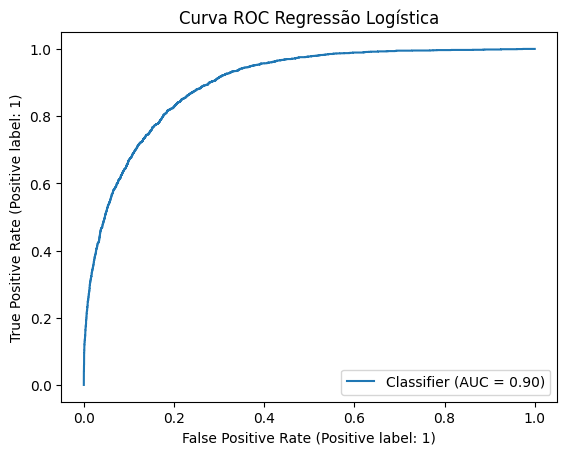

In [75]:
#visualização gráfica da curva ROC
plt.figure()
RocCurveDisplay.from_predictions(
   y_test, logreg_final_preds)
plt.title('Curva ROC Regressão Logística')
plt.show()

Para calcular as demais métricas da matriz de confusão devemos tornar as probabilidades dados binários. Para isso, utilizaremos a fórmula do classificador de Bayes, assumindo um threshold de 50%.

In [76]:
#binarização dos dados
logreg_final_preds = [0 if x <0.5 else 1 for x in logreg_final_preds]

In [77]:
#cálculo das métricas da matriz de confusão
logreg_accuracy = accuracy_score(y_test, logreg_final_preds)
logreg_precision = precision_score(y_test, logreg_final_preds)
logreg_recall = recall_score(y_test, logreg_final_preds)
logreg_f1 = f1_score(y_test,logreg_final_preds)
logreg_model = "Regressão Logística"

metrics = pd.DataFrame({
    "Model": [logreg_model],
    "AUC": [logreg_final_auc],
    "Accuracy": [logreg_accuracy],
    "Precision": [logreg_precision],
    "Recall": [logreg_recall],
    "F1-score": [logreg_f1]
})

print(metrics)

                 Model   AUC  Accuracy  Precision  Recall  F1-score
0  Regressão Logística 0.899     0.806      0.562   0.832     0.671


In [78]:
#geração da matriz de confusão
cf_matrix = confusion_matrix(y_test, logreg_final_preds)


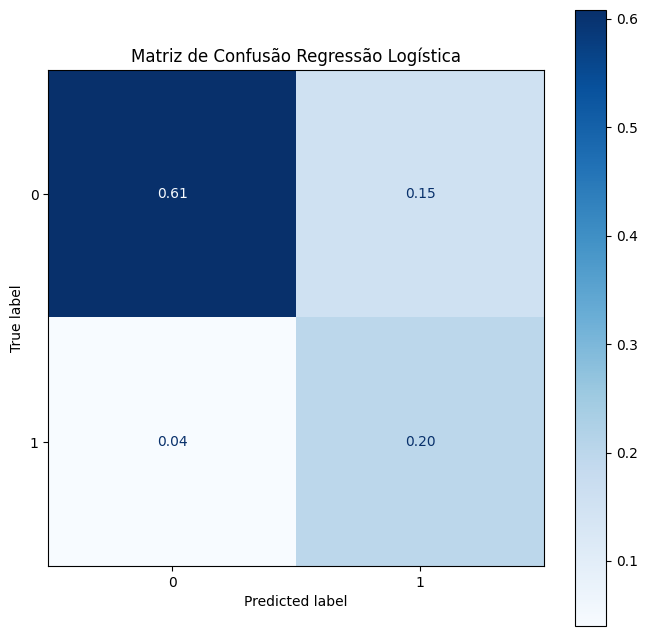

In [79]:
#vizualização gráfica
cf_percent = cf_matrix.astype('float') / cf_matrix.sum() #representação percentual dos quadrantes

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cf_percent, display_labels=logreg_final_model.classes_)

disp.plot(cmap=plt.cm.Blues, ax=ax, values_format=".2f")

plt.title('Matriz de Confusão Regressão Logística')
plt.show()

## 8. SVM

O próximo modelo a ser treinado será o SVM (Support Vector Machine), que se baseia na ideia de maximização da margem, distância de um hiperplano até o ponto mais próximo de cada classe (vetores de suporte), para realizar a classificação.

Os hiperparâmetros foram escolhidos por otimização bayesiana, HyperOpt, acoplado a validação cruzada. A métrica de avaliação usada também foi a área abaixo da curva ROC (AUC).

In [80]:
#definição do espaço de busca de hiperparâmetros
space = {
    'C': hp.loguniform('C', -3, 3),
    'kernel': hp.choice('kernel', ['linear', 'rbf', 'poly'])
}

In [81]:
#função objetivo
def objective(params):
    model = SVC(**params)

    auc_scores = []
    X_train_np = np.array(X_train)
    y_train_np = np.array(y_train)

    kf = KFold(n_splits=3, shuffle=True, random_state=42)

    for train_index, val_index in kf.split(X_train_np):
      x_t, x_v = X_train_np[train_index], X_train_np[val_index]
      y_t, y_v = y_train_np[train_index], y_train_np[val_index]

      model.fit(x_t, y_t)
      preds = model.predict(x_v)
      auc = roc_auc_score(y_v, preds)
      auc_scores.append(auc)

    auc = np.mean(auc_scores)
    return {'loss': -auc, 'status': STATUS_OK}

In [82]:
trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=50, trials=trials)

100%|██████████| 50/50 [27:44<00:00, 33.29s/trial, best loss: -0.7623217704159183]


In [83]:
param_map = {
    'kernel':['linear', 'rbf', 'poly']
}

best_params = {
    'C': float(best['C']),
    'kernel': param_map['kernel'][best['kernel']]
}

svm_final_model = SVC(**best_params)

In [84]:
#performance no conjunto de treinamento com validação cruzada
score = cross_val_score(svm_final_model, X_train, y_train, cv = 5, scoring="roc_auc")
print("AUC treino com cross validation:", score.mean())
svc_score = score.mean()

AUC treino com cross validation: 0.8792597714472947


In [85]:
# avaliação do modelo no conjunto de teste
svm_final_model.fit(X_train, y_train)
svc_preds = svm_final_model.predict(X_test)
auc = roc_auc_score(y_test, svc_preds)
print("AUC no conjunto de teste:", auc)

AUC no conjunto de teste: 0.7602231328268095


A performance no conjunto de teste foi bem abaixo daquela do conjunto de treinamento, indicando um possível overfitting.

Testaremos também o modelo treinado apenas com os hiperparâmetros definidos por default.

In [86]:
#performance no conjunto de teste (não holdout)
svc = SVC()
svc.fit(X_train, y_train)
new_preds = svc.predict(X_test)
new_auc = roc_auc_score(y_test, new_preds)

In [87]:
print("AUC teste:", new_auc)

AUC teste: 0.750806669345732


A performance obtida utilizando HyperOpt ainda foi melhor, portanto, a manteremos.

<Figure size 640x480 with 0 Axes>

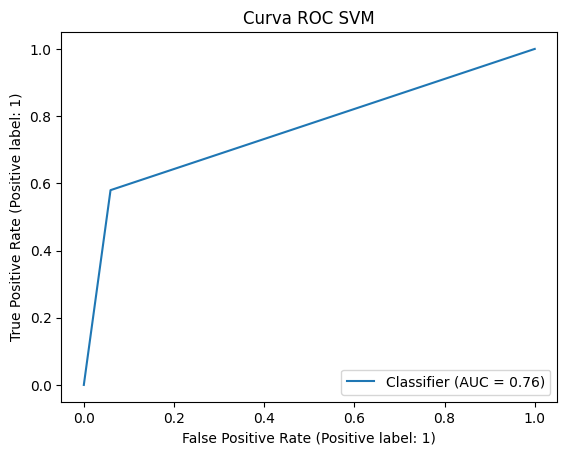

In [88]:
#visualização gráfica da curva ROC
plt.figure()
RocCurveDisplay.from_predictions(
   y_test, svc_preds)
plt.title('Curva ROC SVM')
plt.show()

Para obter as métricas da matriz de confusão, binarizaremos os dados sob threshold de 50%.

In [89]:
#binarização dos dados
svc_preds = [0 if x <0.5 else 1 for x in svc_preds]

In [90]:
svc_accuracy = accuracy_score(y_test, svc_preds)
svc_precision = precision_score(y_test, svc_preds)
svc_recall = recall_score(y_test, svc_preds)
svc_f1 = f1_score(y_test, svc_preds)
svc_model = "SVM"

temp_metrics = pd.DataFrame({
    "Model": [svc_model],
    "AUC": [auc],
    "Accuracy": [svc_accuracy],
    "Precision": [svc_precision],
    "Recall": [svc_recall],
    "F1-score": [svc_f1]
})
metrics = pd.concat([metrics,temp_metrics])
print(metrics)

                 Model   AUC  Accuracy  Precision  Recall  F1-score
0  Regressão Logística 0.899     0.806      0.562   0.832     0.671
0                  SVM 0.760     0.855      0.753   0.580     0.655


In [91]:
#geração de matriz de confusão
cf_matrix = confusion_matrix(y_test, svc_preds)

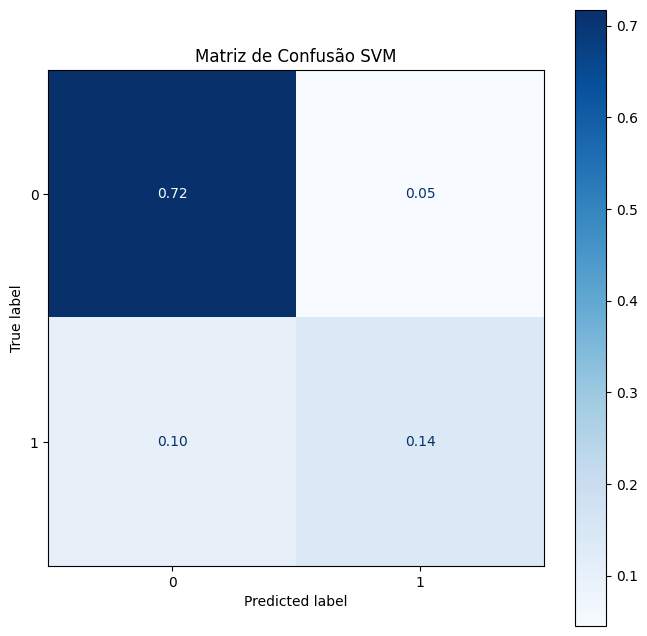

In [92]:
#visualização gráfica da matriz de confusão
cf_percent = cf_matrix.astype('float') / cf_matrix.sum()

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cf_percent)

disp.plot(cmap=plt.cm.Blues, ax=ax, values_format=".2f")

plt.title('Matriz de Confusão SVM')
plt.show()

## 9. Random Forest

O modelo de florestas aleatórias, um algoritmo de bagging baseado em árvores de classificação também foi testado para os dados. Os seus hiperparâmetros será feita por otimização bayesiana, utilizando HyperOpt, acoplada a cross validation, utilizando AUC como função de perda.


In [93]:
#definição do espaço de busca de hiperparâmetros
space = {
    'max_depth': hp.quniform('max_depth', 10, 1200, 10),
    'max_features': hp.choice('max_features', ['sqrt','log2', None]),
    'min_samples_leaf': hp.uniform('min_samples_leaf', 0, 0.5),
    'min_samples_split' : hp.uniform ('min_samples_split', 0, 1)
}

In [94]:
#definição da função objetivo
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def objective(params):
    params = {
        'max_depth': int(params['max_depth']),
        'max_features': params['max_features'],
        'min_samples_leaf': params['min_samples_leaf'],
        'min_samples_split': params['min_samples_split']
    }
    auc_scores = []
    X_train_np = np.array(X_train)
    y_train_np = np.array(y_train)
    rf = RandomForestClassifier(**params)

    for train_index, val_index in kf.split(X_train_np):
      x_t, x_v = X_train_np[train_index], X_train_np[val_index]
      y_t, y_v = y_train_np[train_index], y_train_np[val_index]

      rf.fit(x_t, y_t)
      preds = rf.predict_proba(x_v)[:, 1]
      auc = roc_auc_score(y_v, preds)
      auc_scores.append(auc)

    auc = np.mean(auc_scores)
    return {'loss': -auc, 'status': STATUS_OK}

In [95]:
trials = Trials()
best = fmin(fn=objective,
            space=space,
            algo=tpe.suggest,
            max_evals=100,
            trials=trials)

print("Melhores hiperparâmetros:", best)

100%|██████████| 100/100 [05:00<00:00,  3.01s/trial, best loss: -0.9120593581512015]
Melhores hiperparâmetros: {'max_depth': 200.0, 'max_features': 0, 'min_samples_leaf': 0.001372418028453881, 'min_samples_split': 0.002460345851231774}


In [96]:
param_map = {
            'max_features': ['sqrt','log2', None]
            }

best_params = {
        'max_depth': int(best['max_depth']),
        'max_features': param_map['max_features'][best['max_features']],
        'min_samples_leaf': best['min_samples_leaf'],
        'min_samples_split': best['min_samples_split']
}

rf_final_model = RandomForestClassifier(**best_params)
rf_final_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=200, min_samples_leaf=0.001372418028453881,
                       min_samples_split=0.002460345851231774)

In [97]:
#avaliação da performance no conjunto de treinamento com 10-fold cross validation (random seed diferente)
kf = KFold(n_splits=10, shuffle=True, random_state=43)

auc_scores = []
X_train_np = np.array(X_train)
y_train_np = np.array(y_train)

for train_index, val_index in kf.split(X_train_np):
    x_t, x_v = X_train_np[train_index], X_train_np[val_index]
    y_t, y_v = y_train_np[train_index], y_train_np[val_index]

    rf_final_model.fit(x_t, y_t)
    rf_eval_preds = rf_final_model.predict_proba(x_v)[:, 1]
    auc = roc_auc_score(y_v, rf_eval_preds)
    auc_scores.append(auc)

mean_auc = np.mean(auc_scores)
print(f"Média da AUC com cross validation: {mean_auc:.4f}")

Média da AUC com cross validation: 0.9122


Obteve-se uma excelente performance sobre o conjunto de treinamento avaliado por validação cruzada com uma área abaixo da curva de 0.90, ficando a performance equivalente à da regressão logística.

In [98]:
#avalição da performance no conjunto de teste
rf_final_model.fit(X_train, y_train)
rf_final_preds = rf_final_model.predict_proba(X_test)[:, 1]
rf_final_auc = roc_auc_score(y_test, rf_final_preds)

rf_final_auc

0.9104771408404075

Para o conjunto de teste a performance obtida foi praticamente idêntica, sugerindo uma boa consistência do modelo (right fit).

<Figure size 640x480 with 0 Axes>

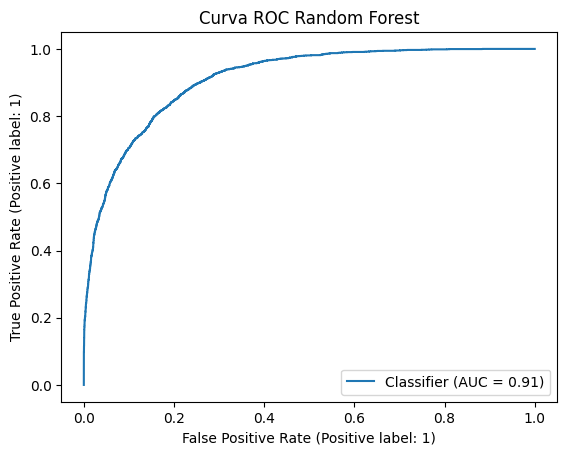

In [99]:
#visualização gráfica da curva ROC
plt.figure()
RocCurveDisplay.from_predictions(
   y_test, rf_final_preds)
plt.title('Curva ROC Random Forest')
plt.show()

In [100]:
#binarização do desfecho
rf_final_preds = [0 if x <0.5 else 1 for x in rf_final_preds]

In [101]:
#métricas da matriz de confusão
rf_accuracy = accuracy_score(y_test, rf_final_preds)
rf_precision = precision_score(y_test, rf_final_preds)
rf_recall = recall_score(y_test, rf_final_preds)
rf_f1 = f1_score(y_test, rf_final_preds)
rf_model = "Random Forest"

temp_metrics = pd.DataFrame({
    "Model": [rf_model],
    "AUC": [rf_final_auc],
    "Accuracy": [rf_accuracy],
    "Precision": [rf_precision],
    "Recall": [rf_recall],
    "F1-score": [rf_f1]
})
metrics = pd.concat([metrics,temp_metrics])
print(metrics)

                 Model   AUC  Accuracy  Precision  Recall  F1-score
0  Regressão Logística 0.899     0.806      0.562   0.832     0.671
0                  SVM 0.760     0.855      0.753   0.580     0.655
0        Random Forest 0.910     0.860      0.785   0.566     0.658


In [102]:
#geração da matriz de confusão
cf_matrix = confusion_matrix(y_test, rf_final_preds)

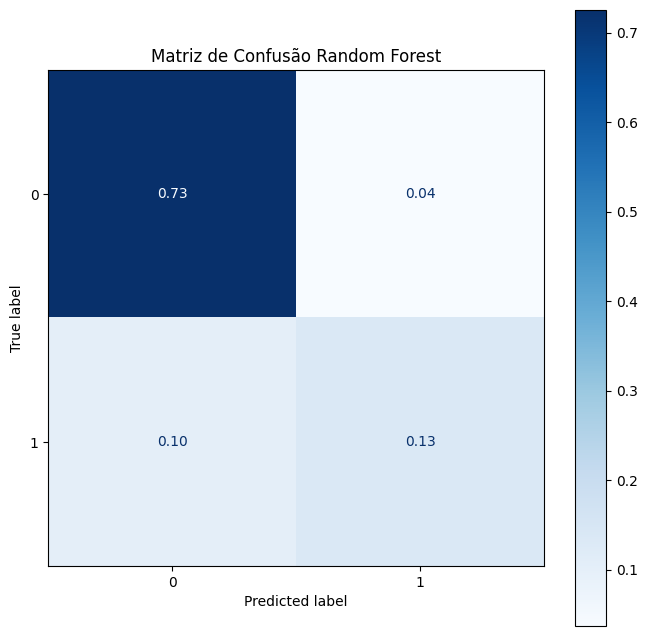

In [103]:
#visualização gráfica
cf_percent = cf_matrix.astype('float') / cf_matrix.sum()

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cf_percent, display_labels=rf_final_model.classes_)

disp.plot(cmap=plt.cm.Blues, ax=ax, values_format=".2f")

plt.title('Matriz de Confusão Random Forest')
plt.show()

## 10. XGBoost

Por fim, testaremos também o XGBoost, algorimo de boosting baseado em árvores de classificação sequenciais. Novamente, a escolha de hiperparâmetros se dará por otimização bayesiana acoplada a validação cruzada, utilizando AUC como função de loss.



In [104]:
#definição do espaço de busca de hiperparâmetros
space = {
    'max_depth': hp.quniform('max_depth', 3, 15, 1),
    'gamma': hp.uniform('gamma', 0, 1),
    'reg_alpha': hp.quniform('reg_alpha', 0, 1, 0.1),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1)
}


In [105]:
#definição de função objetivo
kf = KFold(n_splits=5, shuffle=True, random_state=4)

def objective(params):
    params = {
        'max_depth': int(params['max_depth']),
        'reg_alpha': params['reg_alpha'],
        'colsample_bytree': params['colsample_bytree'],
        'min_child_weight': params['min_child_weight']
    }
    auc_scores = []
    X_train_np = np.array(X_train)
    y_train_np = np.array(y_train)
    clf = xgb.XGBClassifier(**params, use_label_encoder=False, eval_metric='auc')

    for train_index, val_index in kf.split(X_train_np):
      x_t, x_v = X_train_np[train_index], X_train_np[val_index]
      y_t, y_v = y_train_np[train_index], y_train_np[val_index]

      clf.fit(x_t, y_t)
      preds = clf.predict_proba(x_v)[:, 1]
      auc = roc_auc_score(y_v, preds)
      auc_scores.append(auc)

    auc = np.mean(auc_scores)
    return {'loss': -auc, 'status': STATUS_OK}


In [106]:
trials = Trials()
best = fmin(fn=objective,
            space=space,
            algo=tpe.suggest,
            max_evals=100,
            trials=trials)

print("Melhores hiperparâmetros:", best)

100%|██████████| 100/100 [01:34<00:00,  1.05trial/s, best loss: -0.9248238278467016]
Melhores hiperparâmetros: {'colsample_bytree': 0.6505436067759122, 'gamma': 0.7460873908977702, 'max_depth': 4.0, 'min_child_weight': 1.0, 'reg_alpha': 1.0}


In [107]:
best_params = {
    'max_depth': int(best['max_depth']),
    'reg_alpha': best['reg_alpha'],
    'colsample_bytree': best['colsample_bytree'],
    'min_child_weight': best['min_child_weight']
}

xgb_final_model = xgb.XGBClassifier(**best_params, use_label_encoder=False, eval_metric='auc')
xgb_final_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6505436067759122, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='auc', feature_types=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=1.0, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [108]:
#avaliação da performance no conjunto de treinamento utilizando cross validation
kf = KFold(n_splits=10, shuffle=True, random_state=43)

auc_scores = []
X_train_np = np.array(X_train)
y_train_np = np.array(y_train)

for train_index, val_index in kf.split(X_train_np):
    x_t, x_v = X_train_np[train_index], X_train_np[val_index]
    y_t, y_v = y_train_np[train_index], y_train_np[val_index]

    xgb_final_model.fit(x_t, y_t)
    xgb_eval_preds = xgb_final_model.predict_proba(x_v)[:, 1]
    auc = roc_auc_score(y_v, xgb_eval_preds)
    auc_scores.append(auc)

mean_auc = np.mean(auc_scores)
print(f"Média da AUC com cross validation: {mean_auc:.4f}")

Média da AUC com cross validation: 0.9245


De todos os modelos testados o XGBoost obteve a melhor performance sobre o conjunto de treinamento com uma área abaixo da curva de 0.92.

In [109]:
#avalição da performance no conjunto de teste (não hold out)
xgb_final_model.fit(X_train, y_train)
xgb_final_preds = xgb_final_model.predict_proba(X_test)[:, 1]
xgb_final_auc = roc_auc_score(y_test, xgb_final_preds)

xgb_final_auc

0.924703139665598

Curiosamente, a performance no conjunto de teste foi ainda ligeiramente maior em relação àquela do conjunto de treinamento, atestando a consistência e o poder preditivo desse modelo.

<Figure size 640x480 with 0 Axes>

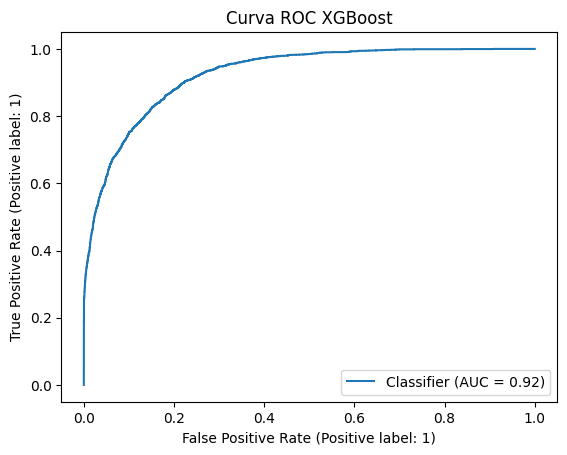

In [110]:
#visualização da curva ROC
plt.figure()
RocCurveDisplay.from_predictions(
   y_test, xgb_final_preds)
plt.title('Curva ROC XGBoost')
plt.show()

In [111]:
#binarização das predições para permitir cálculo correto das métricas
xgb_final_preds = [0 if x <0.5 else 1 for x in xgb_final_preds]

In [112]:
#métricas de avaliação de performance
accuracy = accuracy_score(y_test, xgb_final_preds)
precision = precision_score(y_test, xgb_final_preds)
recall = recall_score(y_test, xgb_final_preds)
f1 = f1_score(y_test, xgb_final_preds)
model = "XGboost"

temp_metrics = pd.DataFrame({
    "Model": [model],
    "AUC": [xgb_final_auc],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1-score": [f1]
})
metrics = pd.concat([metrics, temp_metrics])
print(metrics)

                 Model   AUC  Accuracy  Precision  Recall  F1-score
0  Regressão Logística 0.899     0.806      0.562   0.832     0.671
0                  SVM 0.760     0.855      0.753   0.580     0.655
0        Random Forest 0.910     0.860      0.785   0.566     0.658
0              XGboost 0.925     0.872      0.788   0.630     0.700


In [113]:
#geração da matriz de confusão
cf_matrix = confusion_matrix(y_test, xgb_final_preds)

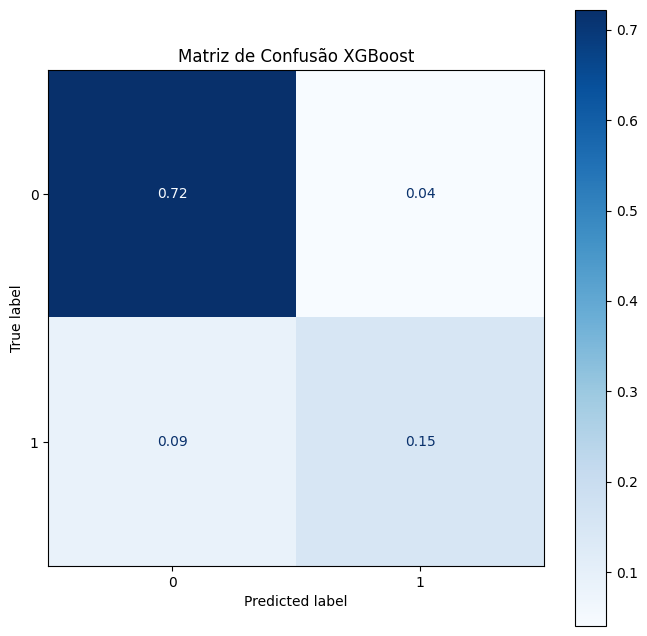

In [114]:
#mostrar o percentual do total em cada quadrante
cf_percent = cf_matrix.astype('float') / cf_matrix.sum()

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cf_percent, display_labels=xgb_final_model.classes_)

disp.plot(cmap=plt.cm.Blues, ax=ax, values_format=".2f")

plt.title('Matriz de Confusão XGBoost')
plt.show()

## 12. Submissão

In [115]:
metrics

,Model,AUC,Accuracy,Precision,Recall,F1-score
0,Regressão Logística,0.899,0.806,0.562,0.832,0.671
0,SVM,0.760,0.855,0.753,0.580,0.655
0,Random Forest,0.910,0.860,0.785,0.566,0.658
0,XGboost,0.925,0.872,0.788,0.630,0.700


Comparando os quatro modelos testados, percebemos que todos apresentam boa performance para a predição de renda baseado nos dados contidos na base Adult. Entretanto, nota-se que o SVM teve AUC abaixo da média dos demais, muito embora sua acurácia tenha sido equivalente. Enquanto isso, o XGBoost se sobressaiu, superando a Regressão Logística e o Random Forest, não apenas para área abaixo da curva, como também para acurácia e f1-score. Quanto à revocação, a regressão logística superou os demais modelos, enquanto a precisão foi maior no Random Forest.

Devido à performance superior por AUC e acurácia o modelo do XGBoost foi escolhido para ser usado na predições finais a serem submetidas no Kaggle.

In [116]:
#formatação das predições para submissão final
final_X_train = pd.concat([X_train, X_test])
final_y_train = pd.concat([y_train, y_test])

#modelo do xgboost com hiperparâmetros treinados anteriormente
xgb_final_model.fit(final_X_train, final_y_train.values.ravel())
pred = xgb_final_model.predict(final_test)

pred = ['>50K' if x == 1 else '<=50K' for x in pred]
Id = [i for i in range(0,len(final_test))]
df = pd.DataFrame(({'Id':Id, 'income':pred}))
df.head(10)

,Id,income
0,0,<=50K
1,1,>50K
2,2,<=50K
3,3,<=50K
4,4,>50K
5,5,<=50K
6,6,>50K
7,7,>50K
8,8,<=50K
9,9,<=50K


In [117]:
df.to_csv("submission.csv",index=False) #salvar em arquivo .csv